# 02 · Revenue-per-User A/B Test (continuous, skewed metric)

**Business question.** We changed the pricing page and want to know whether it moves **average revenue per user (ARPU)**. Revenue is a classic *heavy-tailed* metric: most users spend little, a few spend a lot. That skew has consequences for which test we trust.

This notebook shows:

1. Sizing a test for a **continuous** metric.
2. Welch's t-test (robust to unequal variances) on ARPU.
3. Why we cross-check with the **Mann-Whitney** test on skewed data.
4. Reporting with effect size (Cohen's d).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ab_toolkit.power import sample_size_for_mean
from ab_toolkit.tests import means_test, mann_whitney_test
from ab_toolkit.report import generate_report

rng = np.random.default_rng(7)

## 1. Plan: how many users for a continuous metric?

From historical data ARPU is about **\$16** with a standard deviation of roughly **\$28** (σ ≫ mean — that's the skew talking). We want to detect a **\$1.50** absolute lift (≈ 9% relative) at 80% power.

In [2]:
baseline_mean = 16.0
historical_std = 28.0   # pre-experiment estimate; the true tail is even heavier

n_per_arm = sample_size_for_mean(
    std=historical_std,
    mde=1.5,          # detect a $1.50 lift in ARPU
    alpha=0.05,
    power=0.80,
)
print(f'Required sample size per arm: {n_per_arm:,}')

Required sample size per arm: 5,471


## 2. Simulate skewed revenue

We model revenue as a mix: many users spend \$0 (did not purchase) and purchasers draw from a log-normal distribution. The treatment lifts ARPU by lifting both the purchase rate and the average order value.

In [3]:
def simulate_revenue(n, purchase_rate, ln_mean, ln_sigma, rng):
    purchased = rng.random(n) < purchase_rate
    amounts = rng.lognormal(mean=ln_mean, sigma=ln_sigma, size=n)
    return np.where(purchased, amounts, 0.0)

control = simulate_revenue(n_per_arm, 0.30, ln_mean=3.55, ln_sigma=0.9, rng=rng)
treatment = simulate_revenue(n_per_arm, 0.34, ln_mean=3.62, ln_sigma=0.9, rng=rng)

print(f'Control  ARPU: ${control.mean():.2f}  (median ${np.median(control):.2f})')
print(f'Treatment ARPU: ${treatment.mean():.2f}  (median ${np.median(treatment):.2f})')
print(f'Skew check: control max ${control.max():.0f} vs mean ${control.mean():.2f}')

Control  ARPU: $16.36  (median $0.00)
Treatment ARPU: $18.60  (median $0.00)
Skew check: control max $645 vs mean $16.36


## 3. Welch's t-test on the mean

In [4]:
t_result = means_test(
    control, treatment,
    alpha=0.05,
    metric_name='Revenue per user (ARPU)',
)
print(t_result)

A/B Test Result — Revenue per user (ARPU)
  Test:          Welch's t-test (two-sided)
  Control:       16.3568  (n=5,471)
  Treatment:     18.6047  (n=5,471)
  Abs. effect:   2.2479
  Rel. effect:   +13.74%
  95% CI (abs): [0.6887, 3.8071]
  Statistic:     2.8260
  p-value:       0.004722  (alpha=0.05)
  Cohen's d:     0.0540
  Verdict:       SIGNIFICANT at 95% confidence


## 4. Cross-check with Mann-Whitney

Because revenue is heavily skewed, the t-test's reliance on the mean can be swayed by a handful of big spenders. The rank-based Mann-Whitney test asks a subtly different question — *does one arm tend to produce larger values?* — and is robust to the tail. If both agree, we're far more confident.

In [5]:
u_result = mann_whitney_test(
    control, treatment,
    alpha=0.05,
    metric_name='Revenue per user (rank-based)',
)
print(u_result)

print()
agree = t_result.significant == u_result.significant
print(f"Tests agree on significance: {agree}")

A/B Test Result — Revenue per user (rank-based)
  Test:          Mann-Whitney U test (two-sided)
  Control:       0.0000  (n=5,471)
  Treatment:     0.0000  (n=5,471)
  Abs. effect:   0.0000
  Rel. effect:   +nan%
  95% CI (abs): [nan, nan]
  Statistic:     15394248.5000
  p-value:       0.001756  (alpha=0.05)
  Cohen's d:     -0.0286
  Verdict:       SIGNIFICANT at 95% confidence

Tests agree on significance: True


## 5. Decision report

In [6]:
_ = generate_report(t_result, practical_threshold=0.05)

  A/B TEST REPORT — Revenue per user (ARPU)

  RESULTS
    Test used .......... Welch's t-test (two-sided)
    Control ............ 16.3568  (n = 5,471)
    Treatment .......... 18.6047  (n = 5,471)
    Absolute effect .... 2.2479
    Relative effect .... +13.74%
    95% CI (absolute) . [0.6887, 3.8071]
    p-value ............ 0.004722  (alpha = 0.05)
    Effect size ........ 0.0540  (Cohen's d)

  INTERPRETATION
    Statistically significant increase of 13.74% (p = 0.004722 < 0.05). The treatment is likely the cause.

  PRACTICAL SIGNIFICANCE
    The +13.74% effect meets your 5.00% practical threshold.

  RECOMMENDATION
    SHIP CANDIDATE. The treatment shows a significant positive effect. Confirm the effect is practically meaningful and check guardrail metrics before rolling out.



### Visualize the (clipped) revenue distributions

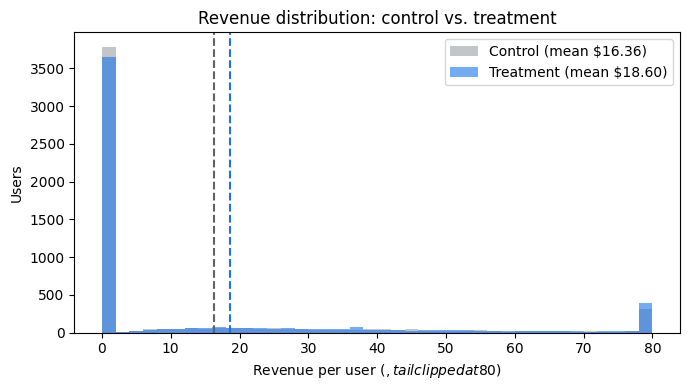

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
clip = 80  # clip the long tail for a readable histogram
bins = np.linspace(0, clip, 41)
ax.hist(np.clip(control, 0, clip), bins=bins, alpha=0.6,
        label=f'Control (mean ${control.mean():.2f})', color='#9aa0a6')
ax.hist(np.clip(treatment, 0, clip), bins=bins, alpha=0.6,
        label=f'Treatment (mean ${treatment.mean():.2f})', color='#1a73e8')
ax.axvline(control.mean(), color='#5f6368', linestyle='--')
ax.axvline(treatment.mean(), color='#1a73e8', linestyle='--')
ax.set_xlabel('Revenue per user ($, tail clipped at $80)')
ax.set_ylabel('Users')
ax.set_title('Revenue distribution: control vs. treatment')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

- ARPU is **right-skewed**, so we did not rely on a single test. Welch's t-test (on the mean) and Mann-Whitney (on ranks) **agree**, which makes the result credible despite the heavy tail.
- Cohen's *d* quantifies the effect size, separating *statistical* significance from *practical* magnitude — important when a large sample can make trivial differences significant.
- For skewed business metrics (revenue, session time, basket size), reporting **both** the parametric and non-parametric result is the honest default.
